In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot(f, a, b, parms, xlabel='x', ylabel='f(x, θ)', title=None, labels=None):
    """
    Plot a parameterized function f(x, θ) over the interval [a, b] for multiple parameters.
    
    Parameters:
    -----------
    f : callable
        Function with signature f(x, theta) where x is the independent variable
        and theta is a parameter
    a : float
        Lower bound of x interval
    b : float
        Upper bound of x interval
    parms : list or array-like
        Collection of parameter values θ to plot
    xlabel : str, optional
        Label for x-axis (default: 'x')
    ylabel : str, optional
        Label for y-axis (default: 'f(x, θ)')
    title : str, optional
        Plot title (default: None)
    labels : list of str, optional
        Legend labels for each parameter (default: 'θ = {value}')
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Create x values
    x = np.linspace(a, b, 500)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot for each parameter
    for i, theta in enumerate(parms):
        y = f(x, theta)
        if labels is not None:
            label = labels[i]
        else:
            label = f'θ = {theta}'
        ax.plot(x, y, label=label, linewidth=2)
    
    # Formatting
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Example: Constant Acceleration

For constant acceleration $a$, the position as a function of time is:

$x(t) = x_0 + v_0 t + \frac{1}{2} a t^2$

Let's plot position vs time for different acceleration values.

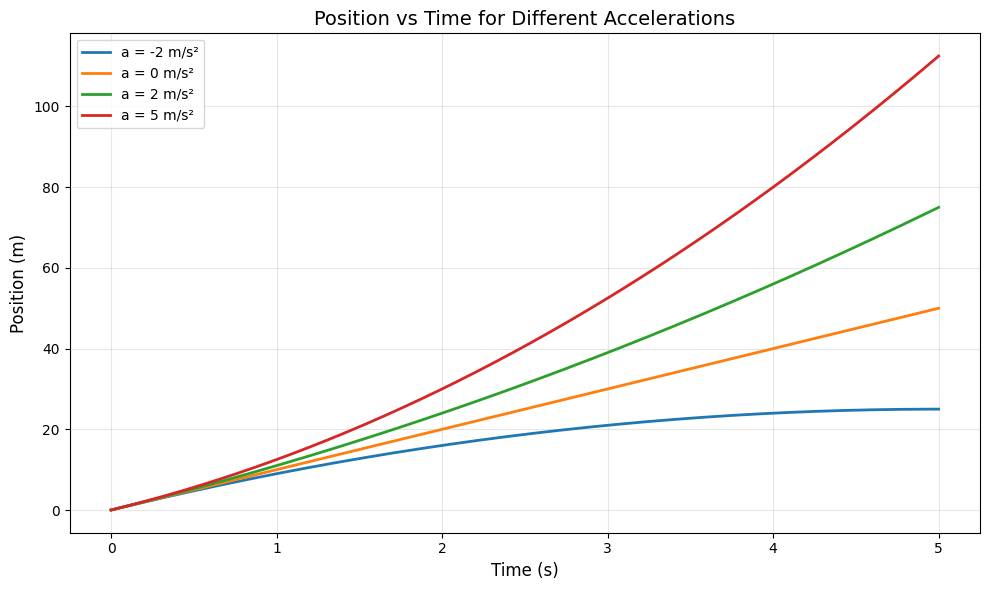

In [5]:
# Define position function for constant acceleration
# x(t, a) = x_0 + v_0*t + (1/2)*a*t^2
# Let's use x_0 = 0, v_0 = 10 m/s

def position(t, a, x0=0, v0=10):
    """Position with constant acceleration"""
    return x0 + v0 * t + 0.5 * a * t**2

# Plot for different accelerations
accelerations = [-2, 0, 2, 5]
fig, ax = plot(position, 0, 5, accelerations, 
               xlabel='Time (s)', 
               ylabel='Position (m)', 
               title='Position vs Time for Different Accelerations',
               labels=[f'a = {a} m/s²' for a in accelerations])

plt.show()

Here is the problem:

There is a particle supposed to go from $0$ to some point $B \in \mathbb{R}^3$, subject to a constant acceleration $a$.
What is the particle's trajectory $x$, according to Euler-Lagrange?
Euler-Lagrange tells us:

$\ddot{x} = -a$

The border conditions are:

$x(0) = 0 \text{, } x(T) = B$

Integrating gives:

$x(t) = - \frac{1}{2} a t^2 + \left (\frac{B}{T} + \frac{1}{2} aT \right ) t$

We are applying this to a boat (or a swimmer, for example) starting on the left bank of a one-unit-wide river at point $(0,0)$, and going to point $B = (1, b_2)$ on the right bank. The current flows from top to bottom with a constant acceleration of $-a_2$. Moving a mass of $m$ units upstream over a distance of $b_2$ units requires an amount of work equal to $amb_2$.
Everything happens in a plane, with coordinates $x_1$ and $x_2$.


Setting $a = \begin{bmatrix}
        0 \\
        a_2
    \end{bmatrix}$
 and $b = \begin{bmatrix}
        1 \\
        b_2
    \end{bmatrix}$, we get, with $t \in [0, T]$:

$x(t) = \frac{t}{T}$

$y(t) = -\frac{1}{2} a_2 t^2 + b_2 \frac{t}{T} + \frac{1}{2}T t$

and expressing $t$ in terms of $x$ yields, with $x \in [0, 1]$:

$y(x) = -\frac{1}{2} a_2 T^2 (x - x^2) + b_2 x$



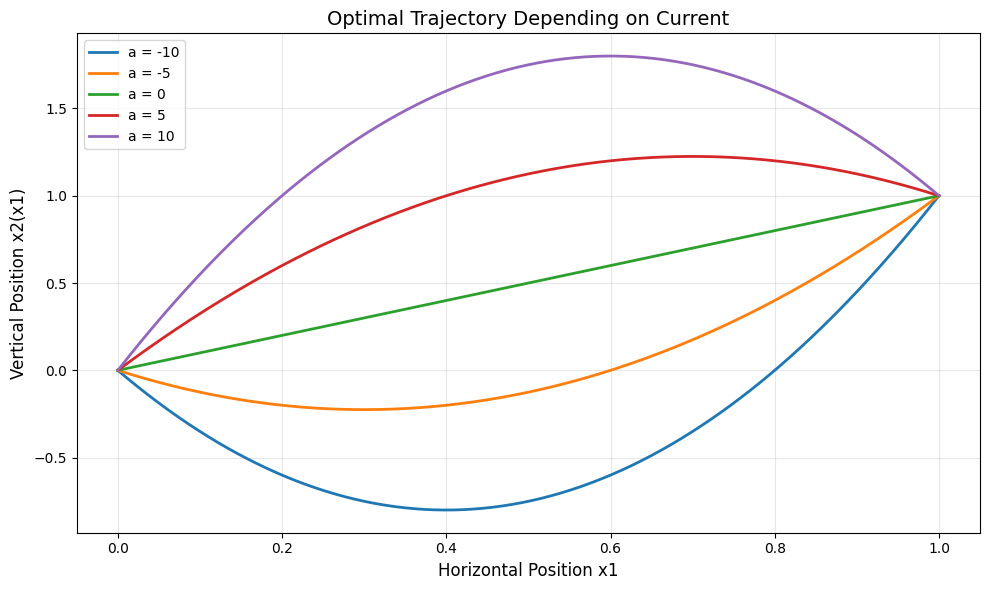

In [11]:
# Define vertical displacement as a function of horizontal displacement
# x2(x1) = 1/2 a T^2(x1 - x1^2) + bx1
# Let's use x_0 = 0, v_0 = 10 m/s

def position(x1, a, b=1, T=1):
    """Position with constant acceleration"""
    return 0.5 * a * T**2 * (x1 - x1**2) + b * x1

# Plot for different accelerations
accelerations = [-10, -5, 0, 5, 10]
fig, ax = plot(position, 0, 1, accelerations, 
               xlabel='Horizontal Position x1', 
               ylabel='Vertical Position x2(x1)', 
               title='Optimal Trajectory Depending on Current',
               labels=[f'a = {a}' for a in accelerations])

plt.show()